# Сравнительный NLP-анализ оригинального английского текста и его перевода на русский язык
Цель проекта: провести комплексный лингвистический и вычислительный анализ пары текстов — оригинала на английском языке и его перевода на русский — с использованием инструментов NLP, чтобы выявить различия в морфологической и синтаксической структуре, устойчивость смысловой и эмоциональной нагрузки при переводе, качество автоматического перевода с точки зрения сохранения тональности и семантики.

In [ ]:
import subprocess
import sys

# Список необходимых библиотек (stopwords-ru удалён)
required_packages = [
    "nltk",
    "spacy",
    "pymorphy3",
    "wordcloud",
    "matplotlib",
    "seaborn",
    "transformers",
    "torch",
    "sentence-transformers"
]

# Установка пакетов через pip
for package in required_packages:
    print(f"Устанавливаем {package}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("\nУстанавливаем модели spaCy...")
spacy_models = ["en_core_web_sm", "ru_core_news_sm"]

for model in spacy_models:
    print(f"Устанавливаем модель: {model}...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", model])

print("\nВсе пакеты установлены.\n")

# Загрузка моделей NLTK
import nltk

nltk_resources = ['punkt', 'stopwords', 'wordnet', 'punkt_tab']

for resource in nltk_resources:
    print(f"Скачиваем ресурс NLTK: {resource}...")
    nltk.download(resource)

print("\nВсе ресурсы NLTK скачаны. Скрипт готов к использованию основного анализа.")


Устанавливаем nltk...
Устанавливаем spacy...
Устанавливаем pymorphy3...
Устанавливаем wordcloud...
Устанавливаем matplotlib...
Устанавливаем seaborn...
Устанавливаем transformers...
Устанавливаем torch...
Устанавливаем sentence-transformers...

Устанавливаем модели spaCy...
Устанавливаем модель: en_core_web_sm...
Устанавливаем модель: ru_core_news_sm...

Все пакеты установлены.

Скачиваем ресурс NLTK: punkt...
Скачиваем ресурс NLTK: stopwords...
Скачиваем ресурс NLTK: wordnet...
Скачиваем ресурс NLTK: punkt_tab...

Все ресурсы NLTK скачаны. Скрипт готов к использованию основного анализа.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# 1. Импорт бибилиотек
# Подключаются все необходимые библиотеки: для обработки текста, лингвистического анализа, визуализации и работы с нейросетевыми моделями.
import re # регулярные выражения для очистки текста
from collections import Counter # подсчёт частот слов
# NLP-библиотеки
import nltk
import spacy
import pymorphy3
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# Анализ тональности
from transformers import pipeline
# Семантическое сходство
from sentence_transformers import SentenceTransformer, util

In [ ]:
# 2. Загрузка текстов
# Чтение исходных текстов из файлов: английский оригинал и его русский перевод.
# Оригинал
with open('/text_en.txt', 'r', encoding='utf-8') as f:
    text_en = f.read()
# Перевод
with open('/text_ru.txt', 'r', encoding='utf-8') as f:
    text_ru = f.read()

In [ ]:
# 3. Предобработка текстов
# Текст приводится к удобному для анализа виду: нижний регистр, удаление лишних пробелов и технических символов.
# Функция очистки текста - приводит текст к нижнему регистру и убирает лишние пробелы
def clean_text(text):
    text = text.lower() # нижний регистр
    text = re.sub(r'<.*?>', '', text) # удаление HTML-тегов (если есть)
    text = re.sub(r'\s+', ' ', text) # удаление лишних пробелов
    return text.strip()
text_en_clean = clean_text(text_en)
text_ru_clean = clean_text(text_ru)

In [ ]:
# 4. Токенизация текстов
# Текст разбивается на отдельные элементы: токены и предложения, с которыми дальше работает NLP.
# Разбиение текста на слова
tokens_en = word_tokenize(text_en_clean)
tokens_ru = word_tokenize(text_ru_clean)
# Разбиение текста на предложения
sents_en = sent_tokenize(text_en_clean)
sents_ru = sent_tokenize(text_ru_clean)

In [ ]:
# 5. Фильтрация слов
# Убираются служебные слова (и, the, of и т.п.), которые не несут смысловой нагрузки и мешают частотному анализу.
stop_en = set(stopwords.words('english'))
stop_ru = set(stopwords.words('russian'))
# Оставляем только слова (без цифр и пунктуации)
words_en = [w for w in tokens_en if w.isalpha() and w not in stop_en]
words_ru = [w for w in tokens_ru if w.isalpha() and w not in stop_ru]

In [ ]:
# 6. Морфологический анализ
# В этом пункте показывается, как слова приводятся к базовой форме и как работает стемминг.
# Английский язык
stemmer_en = PorterStemmer()
lemmatizer_en = WordNetLemmatizer()
print("\nМорфология английского языка:")
for word in words_en[:15]:
    print(f"Слово: {word:15} | Стемминг: {stemmer_en.stem(word):10} | Лемма: {lemmatizer_en.lemmatize(word)}")
# Русский язык
stemmer_ru = SnowballStemmer('russian')
morph = pymorphy3.MorphAnalyzer()
print("\nМорфология русского языка:")
for word in words_ru[:15]:
    print(f"Слово: {word:15} | Стемминг: {stemmer_ru.stem(word):10} | Лемма: {morph.parse(word)[0].normal_form}")


Морфология английского языка:
Слово: nearly          | Стемминг: nearli     | Лемма: nearly
Слово: ten             | Стемминг: ten        | Лемма: ten
Слово: years           | Стемминг: year       | Лемма: year
Слово: passed          | Стемминг: pass       | Лемма: passed
Слово: since           | Стемминг: sinc       | Лемма: since
Слово: dursleys        | Стемминг: dursley    | Лемма: dursleys
Слово: woken           | Стемминг: woken      | Лемма: woken
Слово: find            | Стемминг: find       | Лемма: find
Слово: nephew          | Стемминг: nephew     | Лемма: nephew
Слово: front           | Стемминг: front      | Лемма: front
Слово: step            | Стемминг: step       | Лемма: step
Слово: privet          | Стемминг: privet     | Лемма: privet
Слово: drive           | Стемминг: drive      | Лемма: drive
Слово: hardly          | Стемминг: hardli     | Лемма: hardly
Слово: changed         | Стемминг: chang      | Лемма: changed

Морфология русского языка:
Слово: прошло        

In [ ]:
# 7. Частотный анализ
# Подсчитываем, какие слова встречаются в тексте чаще всего после очистки и удаления стоп-слов.
freq_en = Counter(words_en)
freq_ru = Counter(words_ru)
common_en = freq_en.most_common(15)
common_ru = freq_ru.most_common(15)
print("\nЧастотный анализ (английский текст):")
for word, count in common_en:
    print(f"{word:15} — {count}")
print("\nЧастотный анализ (русский текст):")
for word, count in common_ru:
    print(f"{word:15} — {count}")


Частотный анализ (английский текст):
harry           — 10
dudley          — 7
door            — 4
aunt            — 4
front           — 3
nearly          — 2
ten             — 2
years           — 2
passed          — 2
dursleys        — 2
almost          — 2
exactly         — 2
dursley         — 2
photographs     — 2
showed          — 2

Частотный анализ (русский текст):
гарри           — 10
дадли           — 7
день            — 4
дурсли          — 3
это             — 3
который         — 3
тётя            — 3
дверь           — 3
сон             — 3
рождения        — 3
прошло          — 2
десять          — 2
лет             — 2
фотографии      — 2
показывали      — 2


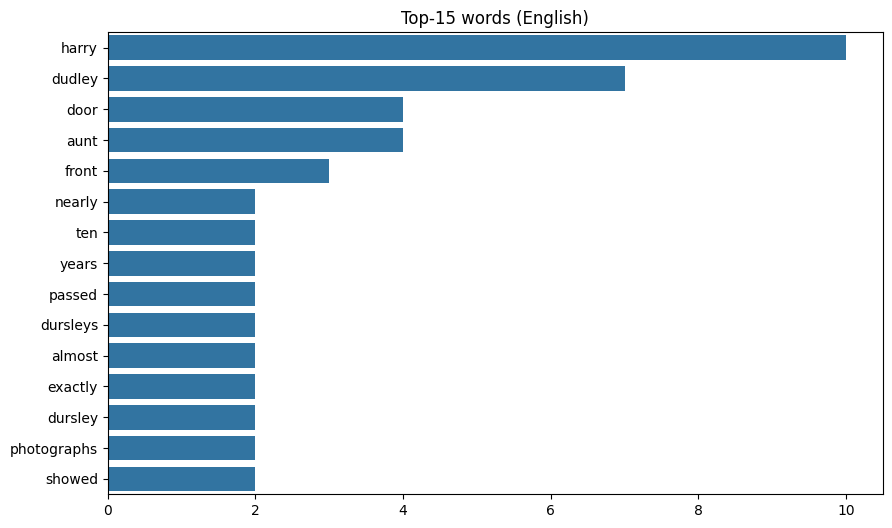

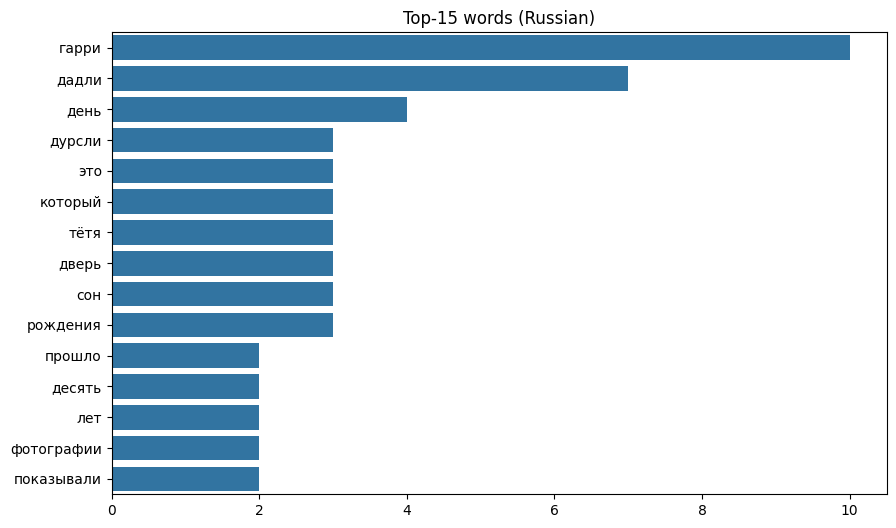

In [ ]:
# 8. Визуализация частот
# Результаты частотного анализа отображаются в виде графиков для наглядного сравнения английского и русского текстов.
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in common_en], y=[x[0] for x in common_en])
plt.title('Top-15 words (English)')
plt.show()
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in common_ru], y=[x[0] for x in common_ru])
plt.title('Top-15 words (Russian)')
plt.show()


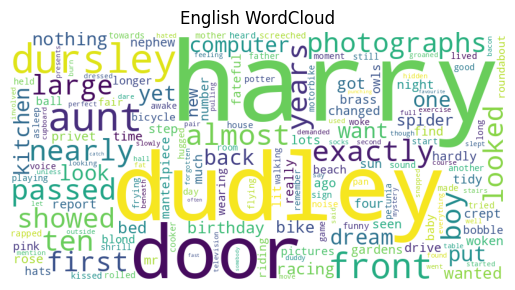

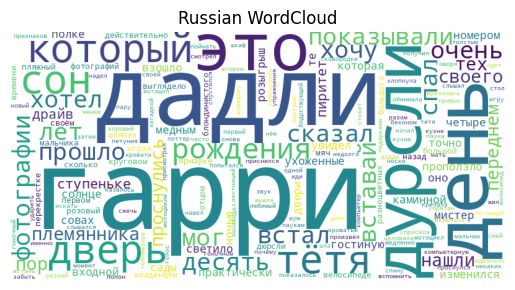

In [ ]:
# 9. Облако слов
# Облако слов визуально показывает ключевые лексемы текста: чем больше слово, тем чаще оно встречается.
wc_en = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words_en))
wc_ru = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words_ru))
plt.imshow(wc_en)
plt.axis('off')
plt.title('English WordCloud')
plt.show()
plt.imshow(wc_ru)
plt.axis('off')
plt.title('Russian WordCloud')
plt.show()

In [ ]:
# 10. Синтаксический анализ
# Анализируется структура предложений: подлежащее, сказуемое, дополнения и их связи.
from spacy import displacy

# Анализ первого предложения
doc_en = nlp_en(sents_en[0])
doc_ru = nlp_ru(sents_ru[0])

print("=" * 70)
print("АНАЛИЗ АНГЛИЙСКОГО ПРЕДЛОЖЕНИЯ:")
print("=" * 70)
print(f"Предложение: {sents_en[0]}\n")

# Визуализация в Jupyter Notebook
displacy.render(doc_en, style='dep', jupyter=True, options={'distance': 90})

print("\n" + "=" * 70)
print("АНАЛИЗ РУССКОГО ПРЕДЛОЖЕНИЯ:")
print("=" * 70)
print(f"Предложение: {sents_ru[0]}\n")

# Визуализация в Jupyter Notebook
displacy.render(doc_ru, style='dep', jupyter=True, options={'distance': 90})

АНАЛИЗ АНГЛИЙСКОГО ПРЕДЛОЖЕНИЯ:
Предложение: nearly ten years had passed since the dursleys had woken up to find their nephew on the front step, but privet drive had hardly changed at all.




АНАЛИЗ РУССКОГО ПРЕДЛОЖЕНИЯ:
Предложение: прошло уже почти десять лет с тех пор, как дурсли проснулись и нашли своего племянника на переднем ступеньке, но пиритет драйв практически не изменился.



In [ ]:
# 11. Анализ тональности
# Используются нейросетевые модели для определения эмоциональной окраски текста (позитив / нейтрал / негатив).
sentiment_en = pipeline('sentiment-analysis', model='cardiffnlp/twitter-roberta-base-sentiment-latest')
sentiment_ru = pipeline('sentiment-analysis', model='blanchefort/rubert-base-cased-sentiment')
result_en = sentiment_en(text_en[:512])
result_ru = sentiment_ru(text_ru[:512])
print("\nТональность английского текста:", result_en)
print("Тональность русского текста:", result_ru)


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Device set to use cpu



Тональность английского текста: [{'label': 'neutral', 'score': 0.6225816011428833}]
Тональность русского текста: [{'label': 'NEGATIVE', 'score': 0.7514740228652954}]


In [ ]:
# 12. Семантическое сходство
# Сравнивается общий смысл английского текста и перевода с помощью векторных представлений (эмбеддингов).
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
emb_en = model.encode(text_en_clean, convert_to_tensor=True)
emb_ru = model.encode(text_ru_clean, convert_to_tensor=True)
similarity = util.cos_sim(emb_en, emb_ru)
print("\nСемантическое сходство текстов:", float(similarity))



Семантическое сходство текстов: 0.7312723994255066


# Вывод
Морфологический разбор показал, что лемматизация точнее отражает словарные формы и грамматические характеристики слов, особенно в русском языке, где морфология сложнее, чем в английском. Частотный анализ и визуализация выявили ключевые слова и темы текста, подтвердив сохранение основных персонажей и сюжетных элементов при переводе. Синтаксический анализ продемонстрировал различия в порядке слов и структуре предложений между языками, что типично для английского и русского языков. Анализ тональности выявил небольшое смещение эмоциональной окраски при переводе, а семантическое сходство показало, что смысл текста в целом сохранён, несмотря на некоторые лексические и структурные различия. В целом, автоматический перевод адекватно передаёт содержание оригинала, но локальные изменения в эмоциональной окраске и синтаксической структуре указывают на возможности для улучшения перевода при сохранении точности и нюансов текста.